Linear Regression on Kaggle data set

In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.read_csv(r"C:\Users\91972\Downloads\archive (13)\StudentPerformance.csv")
df= data.copy()
df.sample()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


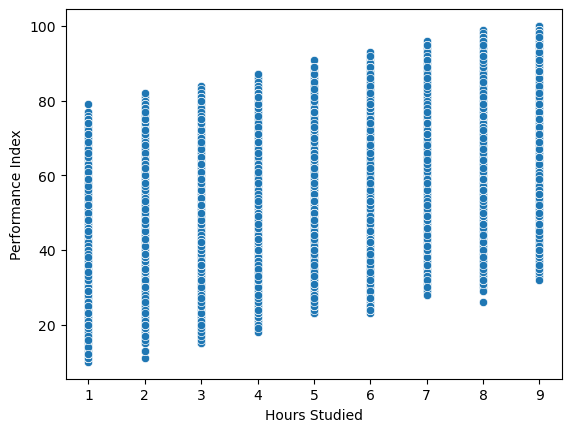

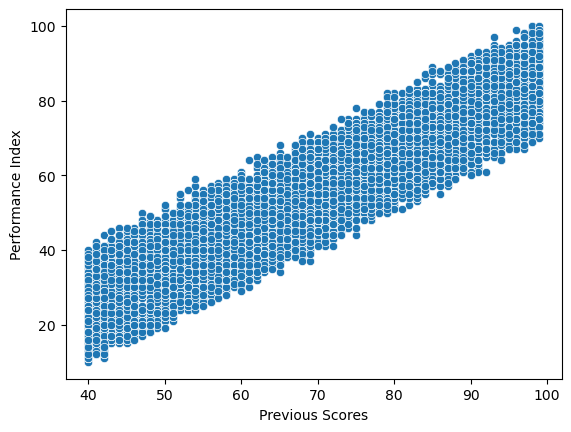

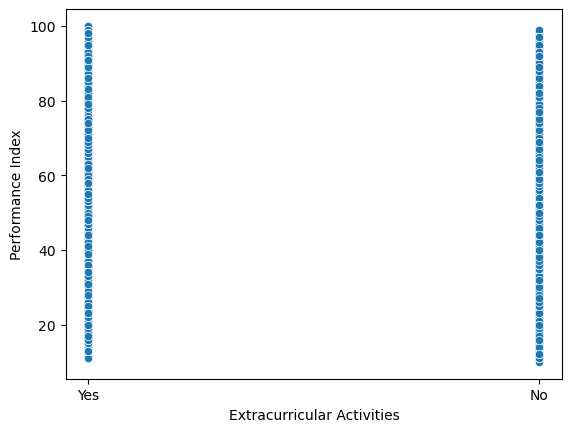

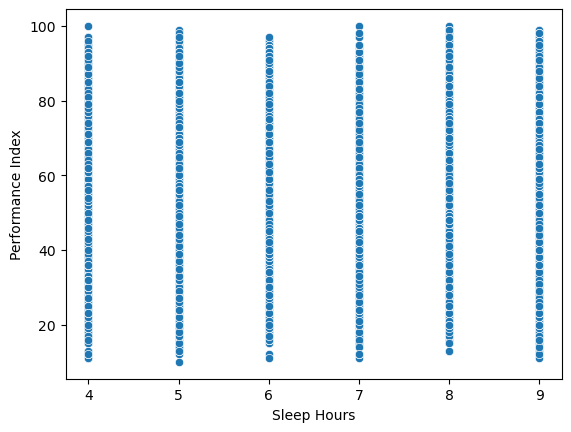

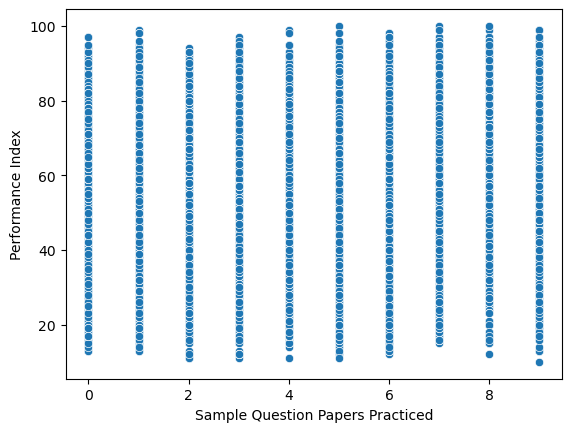

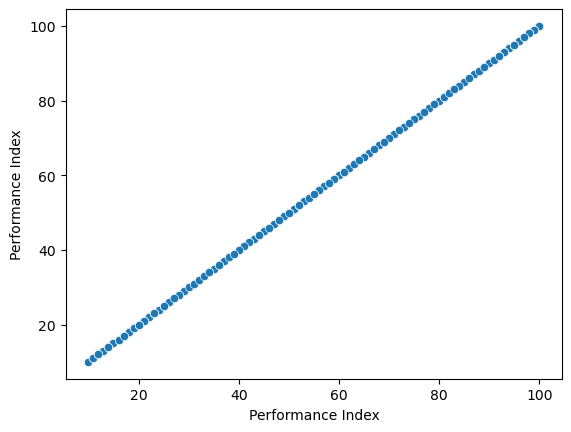

In [11]:
df.sample(5)
for i in df.columns:
    sns.scatterplot(df,x=i,y='Performance Index')
    plt.show()

In [12]:
df.sample(6)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7179,1,72,Yes,4,1,44.0
9251,7,76,No,7,3,64.0
802,3,98,No,4,3,79.0
2259,1,41,Yes,8,8,15.0
7473,8,78,Yes,7,6,70.0
7258,8,92,No,4,6,87.0


In [16]:
from sklearn.model_selection import train_test_split 
X_train1, X_test1, y_train1, y_test1 = train_test_split(df.iloc[:,4],df.iloc[:,5],test_size=0.2,random_state=90)
X_train2, X_test2, y_train2, y_test2 = train_test_split(df.iloc[:,3:5],df.iloc[:,5],test_size=0.2,random_state=90)
X_train3, X_test3, y_train3, y_test3 = train_test_split(df.iloc[:,[1,3,4]],df.iloc[:,5],test_size=0.2,random_state=90)
X_train4, X_test4, y_train4, y_test4 = train_test_split(df.iloc[:,[0,1,3,4]],df.iloc[:,5],test_size=0.2,random_state=90)
# X_train5, X_test5, y_train5, y_test5 = train_test_split(df.iloc[:,[0,1,2,3,4]],df.iloc[:,5],test_size=0.2,random_state=90)

In [17]:
from sklearn.linear_model import LinearRegression
lr1 = LinearRegression()
lr2 = LinearRegression()
lr3 = LinearRegression()
lr4 = LinearRegression()
lr5 = LinearRegression()



In [18]:
X = [X_train1,X_train2,X_train3,X_train4]
lr = [lr1,lr2,lr3,lr4,0]
lr1.fit(X[0].values.reshape(-1,1),y_train1)
lr2.fit(X[1],y_train1)
lr3.fit(X[2],y_train1)
lr4.fit(X[3],y_train1)
# lr1.fit(X[4],y_train1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
x = [X_test1,X_test2,X_test3,X_test4]
y_pred=[0,1,2,3,4]
for i in range(0,4):
    if i ==0:
        y_pred[i] = lr[i].predict(x[i].values.reshape(-1,1))
    else:
        y_pred[i] = lr[i].predict(x[i])    

Y = pd.DataFrame({'Y' : y_test1,
                  'Y_pred1' : y_pred[0],
                  'Y_pred2' : y_pred[1],
                  'Y_pred3': y_pred[2],
                  'Y_pred4' : y_pred[3]})        
Y

,Y,Y_pred1,Y_pred2,Y_pred3,Y_pred4
6125,66.0,56.389145,57.638259,64.061081,66.810970
4195,59.0,54.726840,55.976141,68.746935,63.175147
3673,33.0,55.835043,54.556905,30.698361,33.507593
5643,73.0,56.112094,54.833924,73.495732,73.614239
8017,73.0,54.726840,54.965215,79.910625,71.592998
...,...,...,...,...,...
3798,62.0,56.112094,55.339387,56.765938,62.488021
8124,59.0,54.449789,53.677269,51.317293,57.236381
5050,56.0,55.280942,54.508328,54.041615,57.006704
1363,76.0,54.172738,54.411176,72.351527,75.494466


In [20]:
X_train5 , X_test5 , y_train5,y_test5 = train_test_split(df.drop(['Performance Index'],axis=1),df.iloc[:,5],test_size = 0.2 ,random_state=90)
X_train5
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
X_train5.sample()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
6465,2,80,No,6,1


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
trf1 = ColumnTransformer([('Encod',OneHotEncoder(),[2])],remainder='passthrough')
lr5 = LinearRegression()
pipe = Pipeline([('tr',trf1),
                 ('model',lr5)])
pipe.fit(X_train5,y_train5)
pipe
y_pred[4] = pipe.predict(X_test5)

Y['Y_Pred5']=y_pred[4]
lr[4] =lr5
Y

,Y,Y_pred1,Y_pred2,Y_pred3,Y_pred4,Y_Pred5
6125,66.0,56.389145,57.638259,64.061081,66.810970,66.507312
4195,59.0,54.726840,55.976141,68.746935,63.175147,62.882534
3673,33.0,55.835043,54.556905,30.698361,33.507593,33.183975
5643,73.0,56.112094,54.833924,73.495732,73.614239,73.285555
8017,73.0,54.726840,54.965215,79.910625,71.592998,71.289575
...,...,...,...,...,...,...
3798,62.0,56.112094,55.339387,56.765938,62.488021,62.782368
8124,59.0,54.449789,53.677269,51.317293,57.236381,56.922153
5050,56.0,55.280942,54.508328,54.041615,57.006704,56.688782
1363,76.0,54.172738,54.411176,72.351527,75.494466,75.190960


In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

for i in range(0,5):
    print(f"the MAE of model{i} is {mean_absolute_error(y_test1,y_pred[i])}")
    print(f"the R2-score of model{i} is {r2_score(y_test1,y_pred[i])}")
    print(f"the RMSE of model{i} is {np.sqrt(mean_squared_error(y_test1,y_pred[i]))}",end="\n\n")

the MAE of model0 is 16.169204930075363
the R2-score of model0 is 0.0022427906868061065
the RMSE of model0 is 19.146263109969503

the MAE of model1 is 16.138811964087356
the R2-score of model1 is 0.00569655258193591
the RMSE of model1 is 19.113096745768804

the MAE of model2 is 6.43370261367085
the R2-score of model2 is 0.8455150113545027
the RMSE of model2 is 7.5338111256731874

the MAE of model3 is 1.5975743306082282
the R2-score of model3 is 0.9891112475897292
the RMSE of model3 is 2.0001411593414247

the MAE of model4 is 1.5758905460090182
the R2-score of model4 is 0.9893507191466113
the RMSE of model4 is 1.9780247705956275



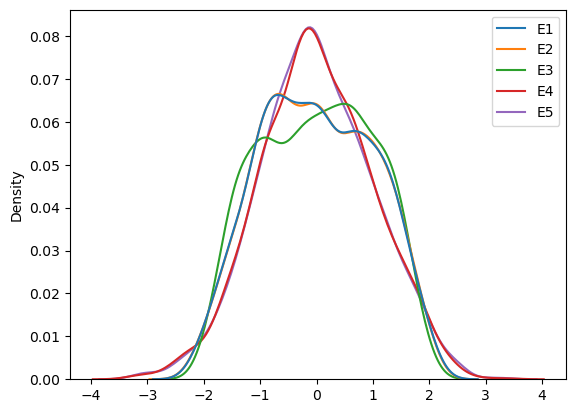

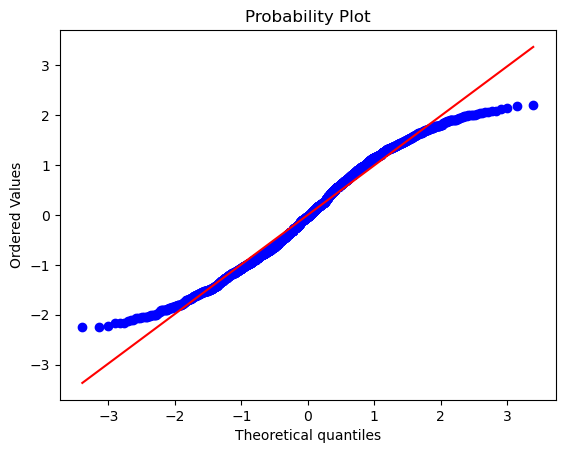

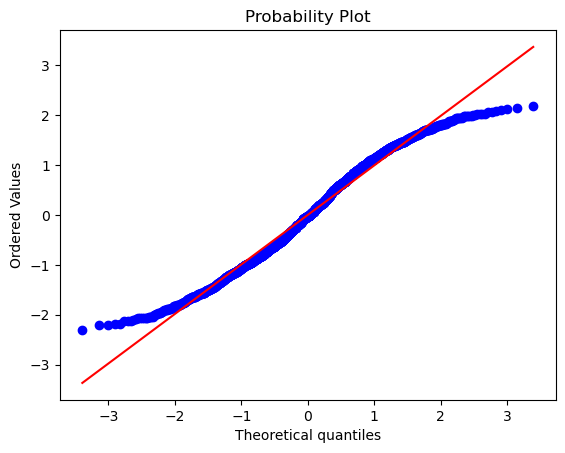

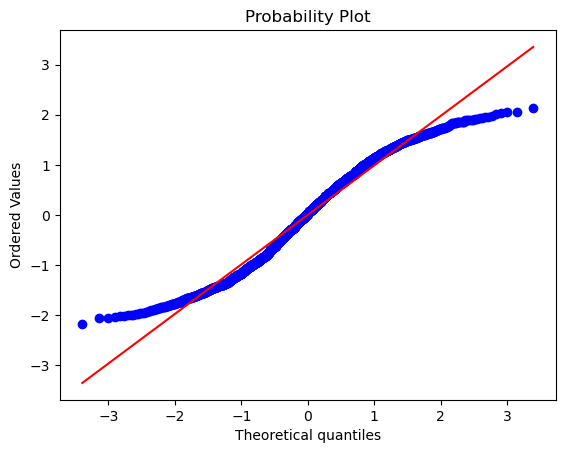

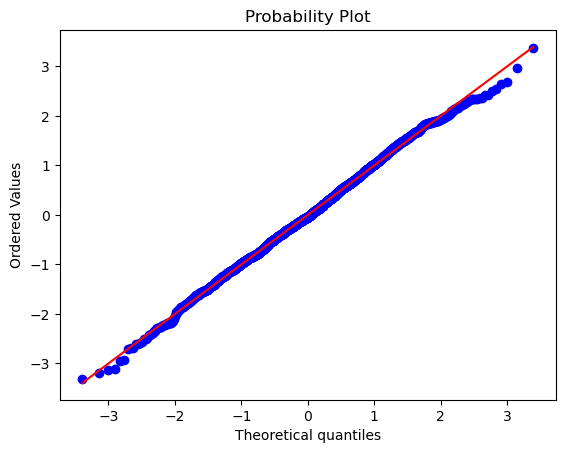

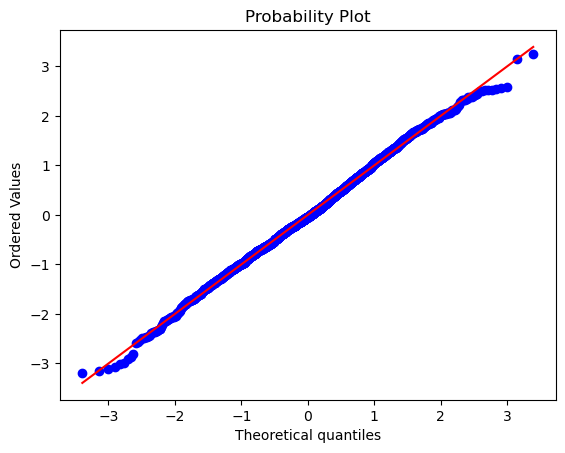

In [41]:
residual = pd.DataFrame({'E1':Y.iloc[:,0]-Y.iloc[:,1],
                         'E2':Y.iloc[:,0]-Y.iloc[:,2],
                         'E3':Y.iloc[:,0]-Y.iloc[:,3],
                         'E4':Y.iloc[:,0]-Y.iloc[:,4],
                         'E5':Y.iloc[:,0]-Y.iloc[:,5],})
residual= residual.reset_index()
residual.drop('index',axis=1,inplace=True)
residual
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()
residuall = sd.fit_transform(residual)
sd_residual = pd.DataFrame(residuall,columns=residual.columns)
sns.kdeplot(sd_residual)
plt.show()


import scipy.stats as st
for i in range(0,5):
    st.probplot(sd_residual.iloc[:,i],plot=plt)
    plt.show()

In [42]:
print("Model 5 is best")

Model 5 is best
